In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from selenium import webdriver
from selenium.webdriver.common.by import By
# from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
# from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.edge.options import Options
from selenium.webdriver.edge.service import Service
# from msedge.selenium_tools import EdgeOptions, Edge
from selenium.webdriver.support.ui import WebDriverWait
from tqdm import tqdm
import warnings
import os,sys, fnmatch
from datetime import datetime as dt
import datetime
import quandl
import nasdaqdatalink
import time
import plotly.express as px
import zipfile
import itertools
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from statsmodels.tsa.arima.model import ARIMA
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.layers import LSTM
from IPython.display import SVG
#from keras.utils.vis_utils import model_to_dot

options = Options()
# options = EdgeOptions()
options.add_experimental_option("excludeSwitches", ["enable-automation",'enable-logging'])
options.add_experimental_option('useAutomationExtension', False)
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument("--disable-extensions")
#options.add_argument(f"--proxy-server='default://'")
#options.add_argument("--proxy-bypass-list=*")
options.add_argument("--start-maximized")
#options.add_argument('--headless')
options.add_argument('--disable-gpu')
options.use_chromium = True
options.add_argument('--disable-dev-shm-usage')
options.add_argument('--no-sandbox')
options.add_argument("--enable-javascript")
options.add_argument('--ignore-certificate-errors')
options.add_argument("--window-size=1920,1080")
options.add_argument('--inprivate')
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/113.0.0.0 Safari/537.36 Edg/113.0.1774.50")
options.add_argument("--timeout=30")  # Set timeout value to 30 seconds
warnings.filterwarnings('ignore')

if os.path.exists('Downloads'):
    os.rmdir('Downloads')
quandl.ApiConfig.api_key = 'tkEdMCGk39PvsMLdnNDV'
today = dt.now().strftime('%d-%m-%y')

In [2]:
def find(pattern, path):
    for root, dirs, files in os.walk(path):
        for name in files:
            if fnmatch.fnmatch(name, pattern):
                return name

In [3]:
if (not os.path.exists(f"{today}\{'nasdaq_screener.csv'}")) or (not os.path.exists(f"{today}\{'BSE_metadata.csv'}")):
    dir = f"D:\\Stock Prediction\{today}"
    prefs={"download.default_directory":dir}
    options.add_experimental_option("prefs",prefs)
    #getting available stocks on NASDAQ
    driver = webdriver.Edge(service = Service(r"D:\Stock Prediction\msedgedriver.exe"), options = options)
    # driver = Edge(executable_path = r"msedgedriver.exe", options = options)
    if not os.path.exists(f"{today}\{'nasdaq_screener.csv'}"):
        driver.get('https://www.nasdaq.com/market-activity/stocks/screener')
        driver.find_element(By.XPATH,'/html/body/div[2]/div/main/div[2]/article/div[3]/div[1]/div/div/div[3]/div[2]/div[2]/div/button').click()
        while not find('nasdaq*',today):
            pass
        while find('*.crdownload',today):
            pass
        os.rename(f'{today}\{find("nasdaq*",today)}',f'{today}\{"nasdaq_screener.csv"}')
    if not os.path.exists(f"{today}\{'BSE_metadata.csv'}"):
        driver.get('https://data.nasdaq.com/api/v3/databases/BSE/metadata?api_key=tkEdMCGk39PvsMLdnNDV')
        while not find('BSE_metadata.csv.zip',today):
            pass
        while find('BSE_metadata.csv.zip.crdownload',today):
            pass
        with zipfile.ZipFile(f"{today}\BSE_metadata.csv.zip","r") as zip_ref:
            zip_ref.extractall(f"{today}")
    driver.quit()
    if os.path.exists(f"{today}\{find('nasdaq_screener_*',today)}"):
        os.remove(f"{today}\{find('nasdaq_screener_*',today)}")
    if os.path.exists(f"{today}\{'BSE_metadata.csv.zip'}"):
        os.remove(f"{today}\{'BSE_metadata.csv.zip'}")

In [4]:
#Code for getting available entities
BSE_metadata = pd.read_csv(f'{today}\BSE_metadata.csv')

In [5]:
#Code to get data for BSE entity
# quandl.get('BSE/SPBSTLIP')

In [6]:
Nasdaq_screener = pd.read_csv(f'{today}\{"nasdaq_screener.csv"}')

In [7]:
Nasdaq_screener = Nasdaq_screener.replace(np.nan,'NA')

In [8]:
new_symbols = Nasdaq_screener['Symbol']
new_symbols = new_symbols.apply(lambda x: x.replace(r'/','-').replace('^',r'%5E'))

In [9]:
Nasdaq_screener['new_symbols'] = new_symbols

In [10]:
# for i in Nasdaq_screener['new_symbols']:
#     os.mkdir(f'{today}\{i}')

In [11]:
nasdaq_market = True
if int(input('Which market do you want to search?\n1. NASDAQ\n2. BSE')) == 2:
    nasdaq_market = False

In [12]:
symbol_search = True
if input('Do you want to search stock by symbol?(Y/N)').lower() == 'n':
    symbol_search = False

In [13]:
work_symbol = []
def stock_finder(symbol,text):
    global symbol_search,nasdaq_market,work_symbol
    work_symbol = []
    stock_found = 0
    if nasdaq_market == True:
        if symbol_search == True:
            if symbol in list(Nasdaq_screener['Symbol']):
                stock_found = 1
                work_symbol.append(symbol)
            else:
                stock_found = 0
        else:
            for i in range(Nasdaq_screener.shape[0]):
                if text.lower() in Nasdaq_screener.loc[i,'Name'].lower():
                    stock_found+=1
                    work_symbol.append(Nasdaq_screener.loc[i,'Symbol'])
    else:
        if symbol_search == True:
            if symbol in list(BSE_metadata['code']):
                stock_found = 1
                work_symbol.append(symbol)
            else:
                stock_found = 0
        else:
            for i in range(BSE_metadata.shape[0]):
                if text.lower() in BSE_metadata.loc[i,'name'].lower():
                    stock_found+=1
                    work_symbol.append(BSE_metadata.loc[i,'code'])
    return stock_found

In [14]:
#searching stock by name and symbol
stock_symbol,stock_name = '',''
go = 1
if symbol_search == True:
    str1 = 'symbol'
    str2 = 'name'
else:
    str1 = 'name'
    str2 = 'symbol'
if symbol_search == True:
    stock_symbol = input('Enter the symbol of stock you want to search: ')
else:
    while len(stock_name)<3:
        stock_name = input('Enter the name of stock you want to search (minimum 3 letters): ')
while True:
    stocks = stock_finder(stock_symbol,stock_name)
    if stocks == 0:
        if symbol_search == True:
            str1 = 'symbol'
            str2 = 'name'
        else:
            str1 = 'name'
            str2 = 'symbol'
        stock_choice = input(f'No stock with such {str1} found. Please enter the {str1} again or enter \n1. to change the stock market\n2. to search stock by {str2}\n3. to exit')
        if stock_choice == "1":
            nasdaq_market = False
        elif stock_choice == '2':
            symbol_search = not symbol_search
            if symbol_search == True:
                stock_symbol = input('Enter the symbol of stock you want to search: ')
            else:
                while len(stock_name)<3:
                    stock_name = input('Enter the name of stock you want to search (minimum 3 letters): ')
        elif stock_choice == '3':
            print('Thank you')
            go=0
            break
        else:
            if symbol_search == True:
                stock_symbol = stock_choice
            else:
                stock_name = stock_choice
    elif stocks !=1:
        print('Following Stocks were found.\n')
        if nasdaq_market == True:
            for i in work_symbol:
                print(Nasdaq_screener[Nasdaq_screener['Symbol'] == i][Nasdaq_screener.columns[:2]])
        else:
            for i in work_symbol:
                print(BSE_metadata[BSE_metadata['code'] == i][BSE_metadata.columns[:2]])
        stock_symbol = input('Please enter the symbol of stock you want: ')
        symbol_search = True
    else:
        print('Stock found\n')
        if nasdaq_market == True:
            print(Nasdaq_screener[Nasdaq_screener['Symbol'] == work_symbol[-1]][Nasdaq_screener.columns[:2]])
        else:
            print(BSE_metadata[BSE_metadata['code'] == work_symbol[-1]][BSE_metadata.columns[:2]])
        break
if go==0:
    exit()

Stock found

     Symbol                     Name
6508   TSLA  Tesla Inc. Common Stock


In [15]:
# stock_to_search = input('Enter your stock symbol to search: ')
# if stock_to_search not in list(Nasdaq_screener['Symbol']):
#     print('Stock not found')
# else:
#     print('Stock found\n')
#     print(Nasdaq_screener[Nasdaq_screener['Symbol'] == stock_to_search][Nasdaq_screener.columns[:-1]])

In [16]:
data = pd.DataFrame()
if nasdaq_market == True:
    symbol = Nasdaq_screener[Nasdaq_screener['Symbol'] == work_symbol[-1]]['new_symbols'].values[0]
    if not os.path.exists(f"D:\\Stock Prediction\{today}\{symbol}"):
        os.mkdir(f"D:\\Stock Prediction\{today}\{symbol}")
        dir = f"D:\\Stock Prediction\{today}\{symbol}"
        prefs={"download.default_directory":dir}
        options.add_experimental_option("prefs",prefs)
        #getting stock data from NASDAQ
        driver = webdriver.Edge(service=Service(r"D:\Stock Prediction\msedgedriver.exe"), options=options)
        # driver = Edge(Service = Service(r"D:\Stock Prediction\msedgedriver.exe"), options = options)
        driver.get(f'https://www.nasdaq.com/market-activity/stocks/{symbol}/historical')
        driver.find_element(By.XPATH,'/html/body/div[2]/div/main/div[2]/div[4]/div[3]/div/div[1]/div/div[1]/div[3]/div/div/div/button[6]').click()
        time.sleep(2.5)
        driver.find_element(By.XPATH,'/html/body/div[2]/div/main/div[2]/div[4]/div[3]/div/div[1]/div/div[1]/div[3]/button').click()
        while not find("historical*",f"D:\\Stock Prediction\{today}\{symbol}"):
            pass
        while find("*.crdownload",f"D:\\Stock Prediction\{today}\{symbol}"):
            pass
        driver.quit()
        file_name = find("historical*",f"D:\\Stock Prediction\{today}\{symbol}")
        os.rename(f'D:\\Stock Prediction\{today}\{symbol}\{file_name}',f'D:\\Stock Prediction\{today}\{symbol}\{"data.csv"}')
        data = pd.read_csv(f'D:\\Stock Prediction\{today}\{symbol}\data.csv')
        for i in range(data.shape[0]):
            data.loc[i,'Date'] = dt.strptime(data.loc[i,'Date'],"%m/%d/%Y")
            data.loc[i,'Open'] = float(data.loc[i,'Open'].strip('$'))
            data.loc[i,'Close/Last'] = float(data.loc[i,'Close/Last'].strip('$'))
            data.loc[i,'High'] = float(data.loc[i,'High'].strip('$'))
            data.loc[i,'Low'] = float(data.loc[i,'Low'].strip('$'))
        data.sort_values('Date',inplace=True)
        data.set_index('Date',inplace=True)
    else:
        data = pd.read_csv(f'D:\\Stock Prediction\{today}\{symbol}\data.csv')
        for i in range(data.shape[0]):
            data.loc[i,'Date'] = dt.strptime(data.loc[i,'Date'],"%m/%d/%Y")
            data.loc[i,'Open'] = float(data.loc[i,'Open'].strip('$'))
            data.loc[i,'Close/Last'] = float(data.loc[i,'Close/Last'].strip('$'))
            data.loc[i,'High'] = float(data.loc[i,'High'].strip('$'))
            data.loc[i,'Low'] = float(data.loc[i,'Low'].strip('$'))
        data.sort_values('Date',inplace=True)
        data.set_index('Date',inplace=True)
else:
    data = quandl.get(f'BSE/{work_symbol[-1]}')
data.fillna(0,inplace=True)
data

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-04-07,13.8347,147428071,13.7207,14.4133,13.5673
2014-04-08,14.364,103122143,14.0033,14.4327,13.7613
2014-04-09,14.462,77098176,14.4507,14.5633,14.0593
2014-04-10,13.6127,107817186,14.4547,14.5,13.586
2014-04-11,13.5853,135983692,13.374,13.8,13.24
...,...,...,...,...,...
2024-04-01,175.22,81562130,176.17,176.75,170.21
2024-04-02,166.63,116650600,164.75,167.69,163.43
2024-04-03,168.38,82950140,164.02,168.82,163.28


In [17]:
print('How old data do you want?\n1. 1 week\n2. 1 month\n3. 1 year\n4. 5 years\n5. All history\n6. Input Custom Value')
old = int(input('Please enter from above options: '))
value = data.shape[0]
if old == 1:
    value = 7
elif old == 2:
    value = 22
elif old == 3:
    value = 262
elif old == 4:
    value = 1302
elif old == 6:
    value = int(input('Input the number of days:'))
plt.figure(figsize = (20,10))
if nasdaq_market == True:
    labels = {'x':'Date','y':'Price in $'}
    y = 'Close/Last'
else:
    labels = {'x':'Date','y':'Price in Rs.'}
    y = 'Close'
fig = px.line(x = data.index[-value:],y = data[y][-value:],labels = labels)
fig.show()
input('Press any key to continue: ')

How old data do you want?
1. 1 week
2. 1 month
3. 1 year
4. 5 years
5. All history
6. Input Custom Value


''

<Figure size 2000x1000 with 0 Axes>

## Forecasting

In [18]:
# Preparing Data
scaler = StandardScaler()
train_rec_count = int(len(data.index)*0.7)
if nasdaq_market == True:
    target = data['Close/Last']
    target_train = data.loc[:data.index[train_rec_count-1],'Close/Last']
    target_test = data.loc[data.index[train_rec_count]:,'Close/Last']
else:
    target = data['Close']
    target_train = data.loc[:data.index[train_rec_count-1],'Close']
    target_test = data.loc[data.index[train_rec_count]:,'Close']
target_scaled = pd.DataFrame(scaler.fit_transform(np.array(target).reshape(-1,1)),columns = ['Close'])
target_train_scaled = pd.DataFrame(scaler.transform(np.array(target_train).reshape(-1,1)),columns = ['Close'])
target_test_scaled = pd.DataFrame(scaler.transform(np.array(target_test).reshape(-1,1)),columns = ['Close'])
# months = [x.month for x in data.index]
# years = [x.year for x in data.index]
# day = [x.day for x in data.index]
# feature = np.array([day, months, years]).T
feature = np.array(([dt.timestamp(x) for x in data.index])).reshape(-1,1)
feature_train = np.array(([dt.timestamp(x) for x in data.index[:train_rec_count]])).reshape(-1,1)
feature_test = np.array(([dt.timestamp(x) for x in data.index[train_rec_count:]])).reshape(-1,1)
forecast_date = [data.index[-1]+datetime.timedelta(days=i)for i in range(1,31)]
feature_forecast = np.array([dt.timestamp(x) for x in forecast_date]).reshape(-1,1)
# feature_forecast = np.array([[x.day for x in forecast_date],[x.month for x in forecast_date],[x.year for x in forecast_date]]).T

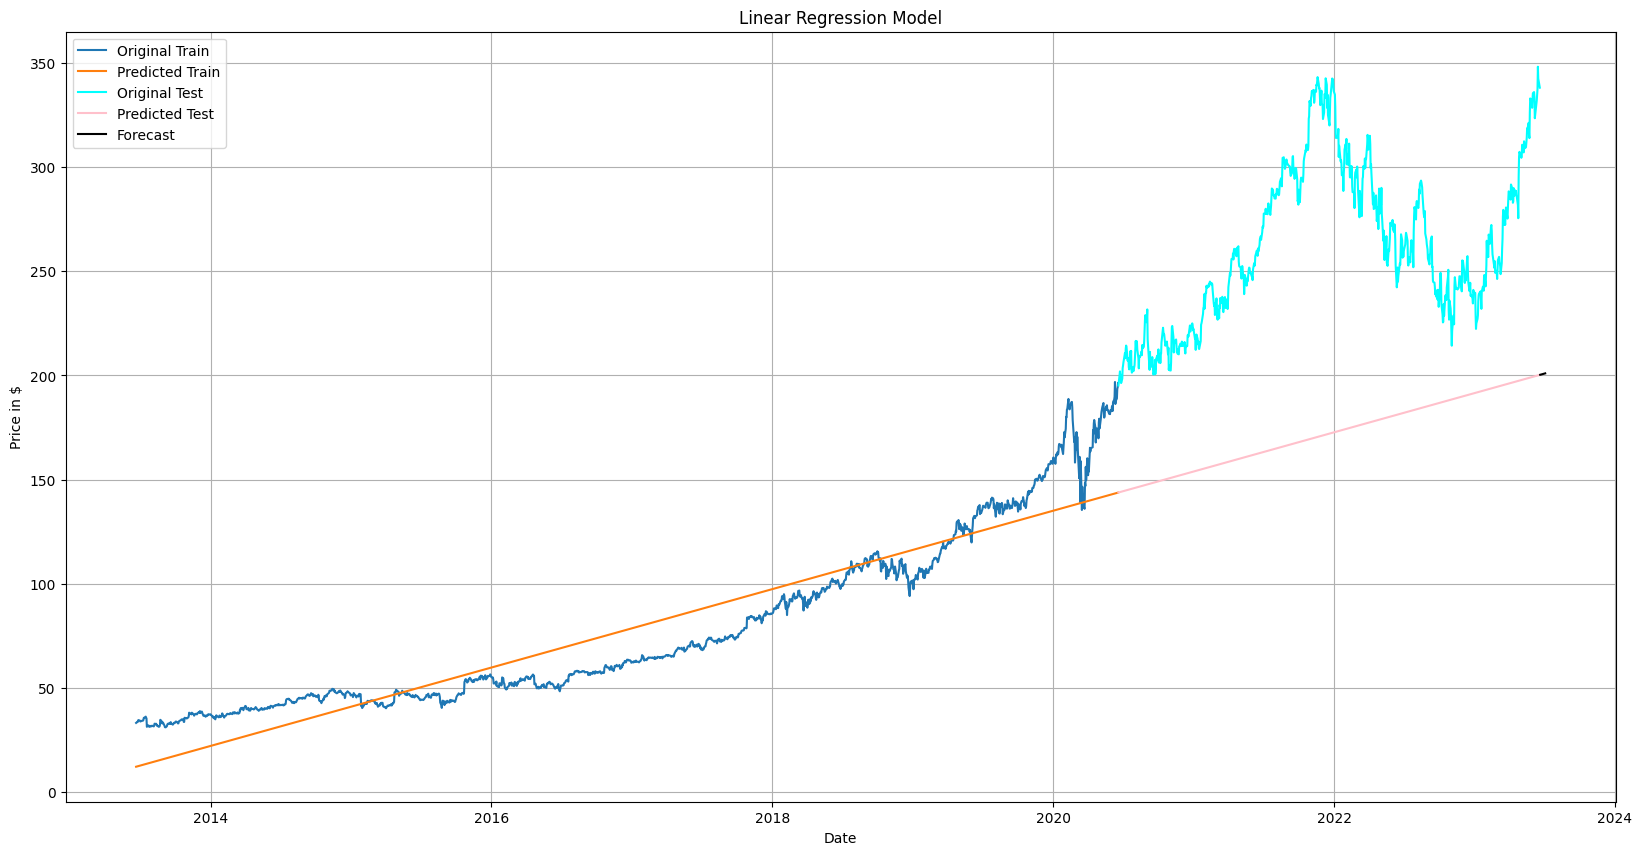

In [22]:
linear_model = LinearRegression()
linear_model.fit(feature_train,target_train_scaled)
pred_train = linear_model.predict(feature_train)
lin_pred_train_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_train).reshape(-1,1)),columns = ['Close'])
forecast = linear_model.predict(feature_forecast)
forecast_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(forecast).reshape(-1,1)),columns = ['Close'])
pred_test = linear_model.predict(feature_test)
lin_pred_test_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_test).reshape(-1,1)),columns = ['Close'])
# plt.figure(figsize=(20,10))
# plt.title('Linear Regression Model')
# plt.plot(data.index[:100],target[:100],label = 'Origzinal')
# plt.plot(data.index[:100],lin_pred_unscaled[:100],label = 'Predicted')
# plt.plot(forecast_date,forecast_unscaled,label = 'Forecast')
# plt.xlabel(labels['x'])
# plt.ylabel(labels['y'])
# plt.legend()
# plt.grid(True)
# plt.show()
plt.figure(figsize=(20,10))
plt.title('Linear Regression Model')
plt.plot(data.index[:train_rec_count],target_train,label = 'Original Train')
plt.plot(data.index[:train_rec_count],lin_pred_train_unscaled,label = 'Predicted Train')
plt.plot(data.index[train_rec_count:],target_test,label = 'Original Test',color='aqua')
plt.plot(data.index[train_rec_count:],lin_pred_test_unscaled,label = 'Predicted Test',color='pink')
plt.plot(forecast_date,forecast_unscaled,label = 'Forecast',color='black')
plt.xlabel(labels['x'])
plt.ylabel(labels['y'])
plt.legend()
plt.grid(True)
plt.show()


In [23]:
print('\n-----------------------Linear Model Stats:-----------------------')
print('\n----------Train----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_train,lin_pred_train_unscaled)))
print('MSE: ',mean_squared_error(target_train,lin_pred_train_unscaled))
print('MAE: ',mean_absolute_error(target_train,lin_pred_train_unscaled))
print('\n----------Test----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_test,lin_pred_test_unscaled)))
print('MSE: ',mean_squared_error(target_test,lin_pred_test_unscaled))
print('MAE: ',mean_absolute_error(target_test,lin_pred_test_unscaled))
input('Press any key to continue')


-----------------------Linear Model Stats:-----------------------

----------Train----------
RMSE:  14.656503956980039
MSE:  214.81310824097156
MAE:  12.178125144180061

----------Test----------
RMSE:  96.67035612832777
MSE:  9345.157753977719
MAE:  90.80307929480901


''

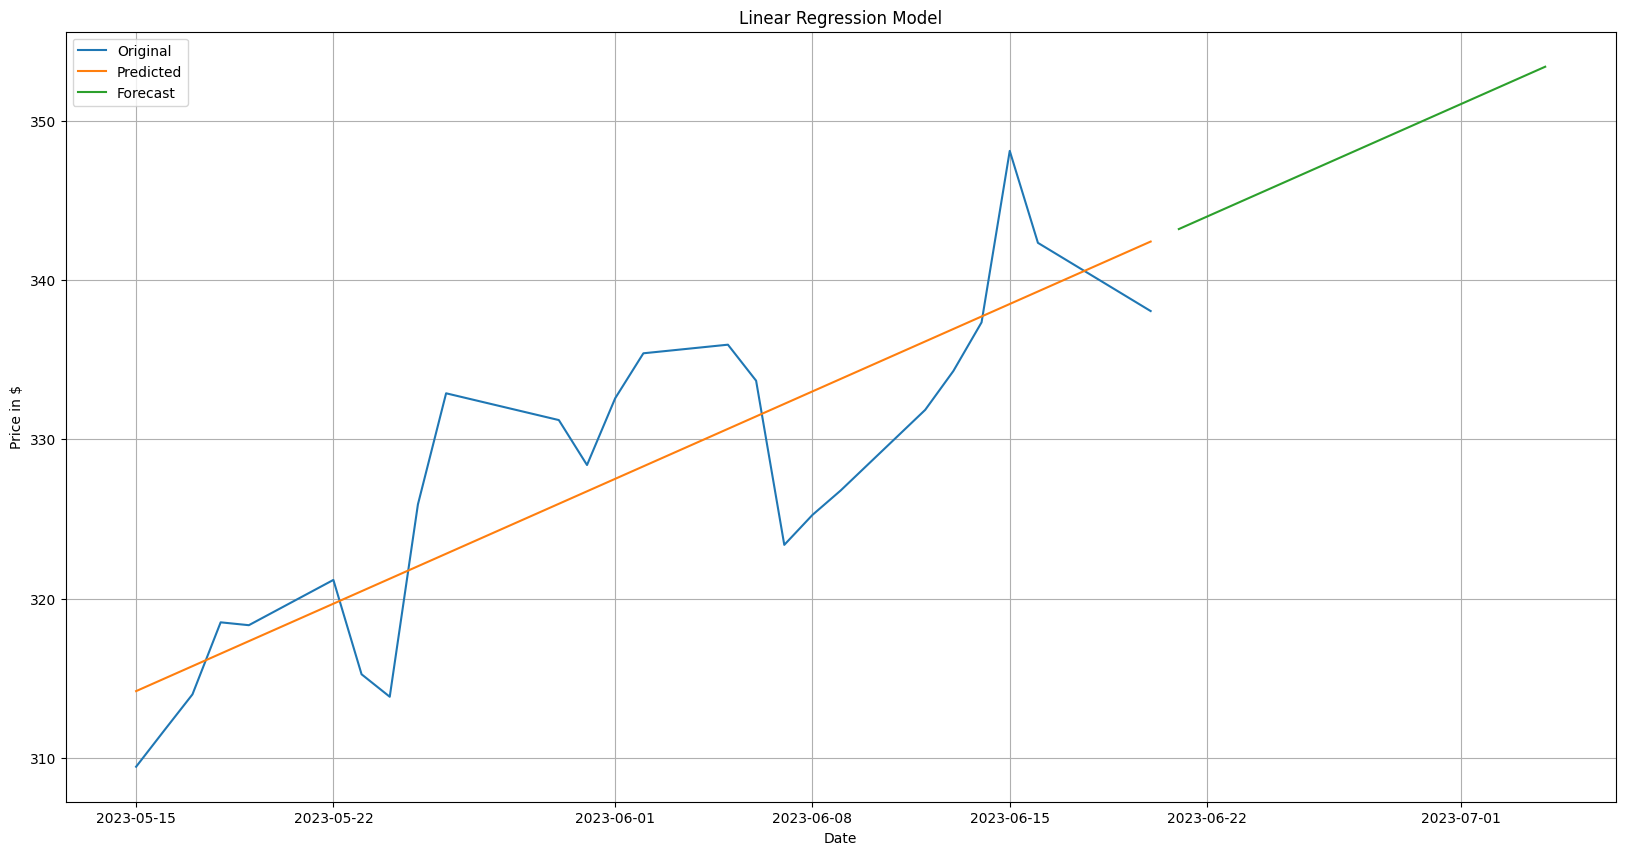


-----------------------Linear Model Stats:-----------------------
RMSE:  293.5995048467207
MSE:  86200.66924623957
MAE:  293.46059999999966


In [24]:
linear_model = LinearRegression()
linear_model.fit(feature[-25:],target_scaled[-25:])
pred = linear_model.predict(feature[-25:])
lin_pred_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred).reshape(-1,1)),columns = ['Close'])
forecast = linear_model.predict(feature_forecast)
forecast_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(forecast).reshape(-1,1)),columns = ['Close'])
plt.figure(figsize=(20,10))
plt.title('Linear Regression Model')
plt.plot(data.index[-25:],target[-25:],label = 'Original')
plt.plot(data.index[-25:],lin_pred_unscaled[-25:],label = 'Predicted')
plt.plot(forecast_date,forecast_unscaled,label = 'Forecast')
plt.xlabel(labels['x'])
plt.ylabel(labels['y'])
plt.legend()
plt.grid(True)
plt.show()
print('\n-----------------------Linear Model Stats:-----------------------')
print('RMSE: ',np.sqrt(mean_squared_error(target[:25],lin_pred_unscaled)))
print('MSE: ',mean_squared_error(target[:25],lin_pred_unscaled))
print('MAE: ',mean_absolute_error(target[:25],lin_pred_unscaled))

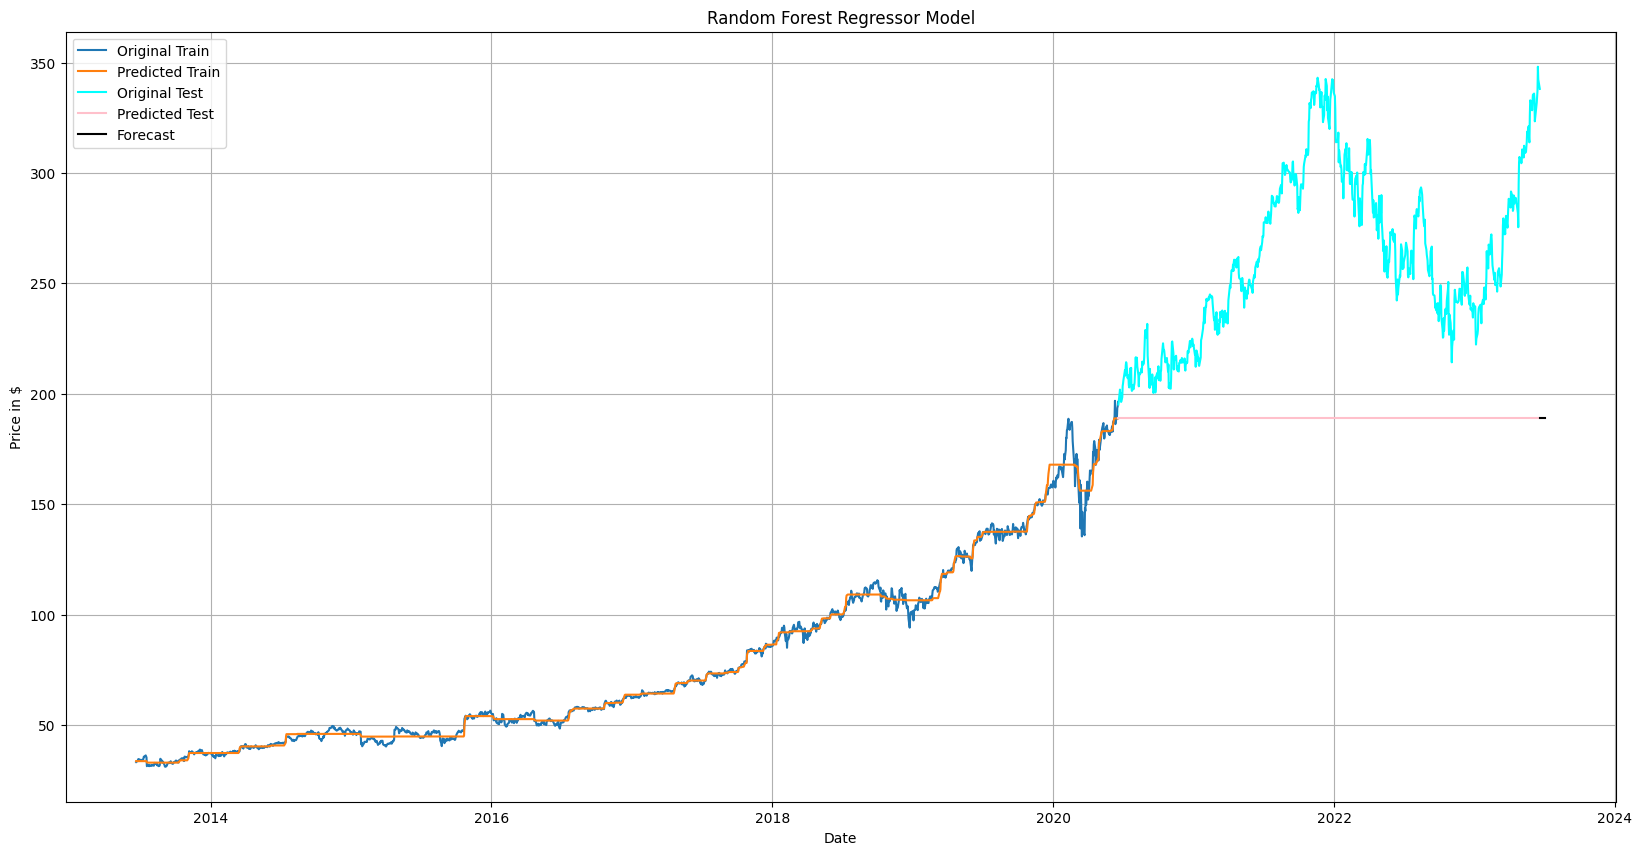

In [25]:
random_forest_model = RandomForestRegressor(n_estimators = 25, max_features = 'log2', max_depth = 5, random_state = 18)
random_forest_model.fit(feature_train,target_train_scaled)

pred_train = random_forest_model.predict(feature_train)
pred_test = random_forest_model.predict(feature_test)

rf_pred_train_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_train).reshape(-1,1)),columns = ['Close'])
rf_pred_test_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_test).reshape(-1,1)),columns = ['Close'])
forecast = random_forest_model.predict(feature_forecast)
forecast_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(forecast).reshape(-1,1)),columns = ['Close'])
plt.figure(figsize=(20,10))
plt.title('Random Forest Regressor Model')
plt.plot(data.index[:train_rec_count],target_train,label = 'Original Train')
plt.plot(data.index[:train_rec_count],rf_pred_train_unscaled,label = 'Predicted Train')
plt.plot(data.index[train_rec_count:],target_test,label = 'Original Test',color='aqua')
plt.plot(data.index[train_rec_count:],rf_pred_test_unscaled,label = 'Predicted Test',color='pink')
plt.plot(forecast_date,forecast_unscaled,label = 'Forecast',color='black')
plt.xlabel(labels['x'])
plt.ylabel(labels['y'])
plt.legend()
plt.grid(True)
plt.show()

In [26]:
print('\n-----------------------Random Forest Model Stats:-----------------------')
print('\n----------Train----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_train,rf_pred_train_unscaled)))
print('MSE: ',mean_squared_error(target_train,rf_pred_train_unscaled))
print('MAE: ',mean_absolute_error(target_train,rf_pred_train_unscaled))
print('\n----------Test----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_test,rf_pred_test_unscaled)))
print('MSE: ',mean_squared_error(target_test,rf_pred_test_unscaled))
print('MAE: ',mean_absolute_error(target_test,rf_pred_test_unscaled))
input('Press any key to continue')


-----------------------Random Forest Model Stats:-----------------------

----------Train----------
RMSE:  2.7545614953885256
MSE:  7.58760903187707
MAE:  1.6237375759312438

----------Test----------
RMSE:  83.05146019529035
MSE:  6897.545040569896
MAE:  73.90861906874903


''

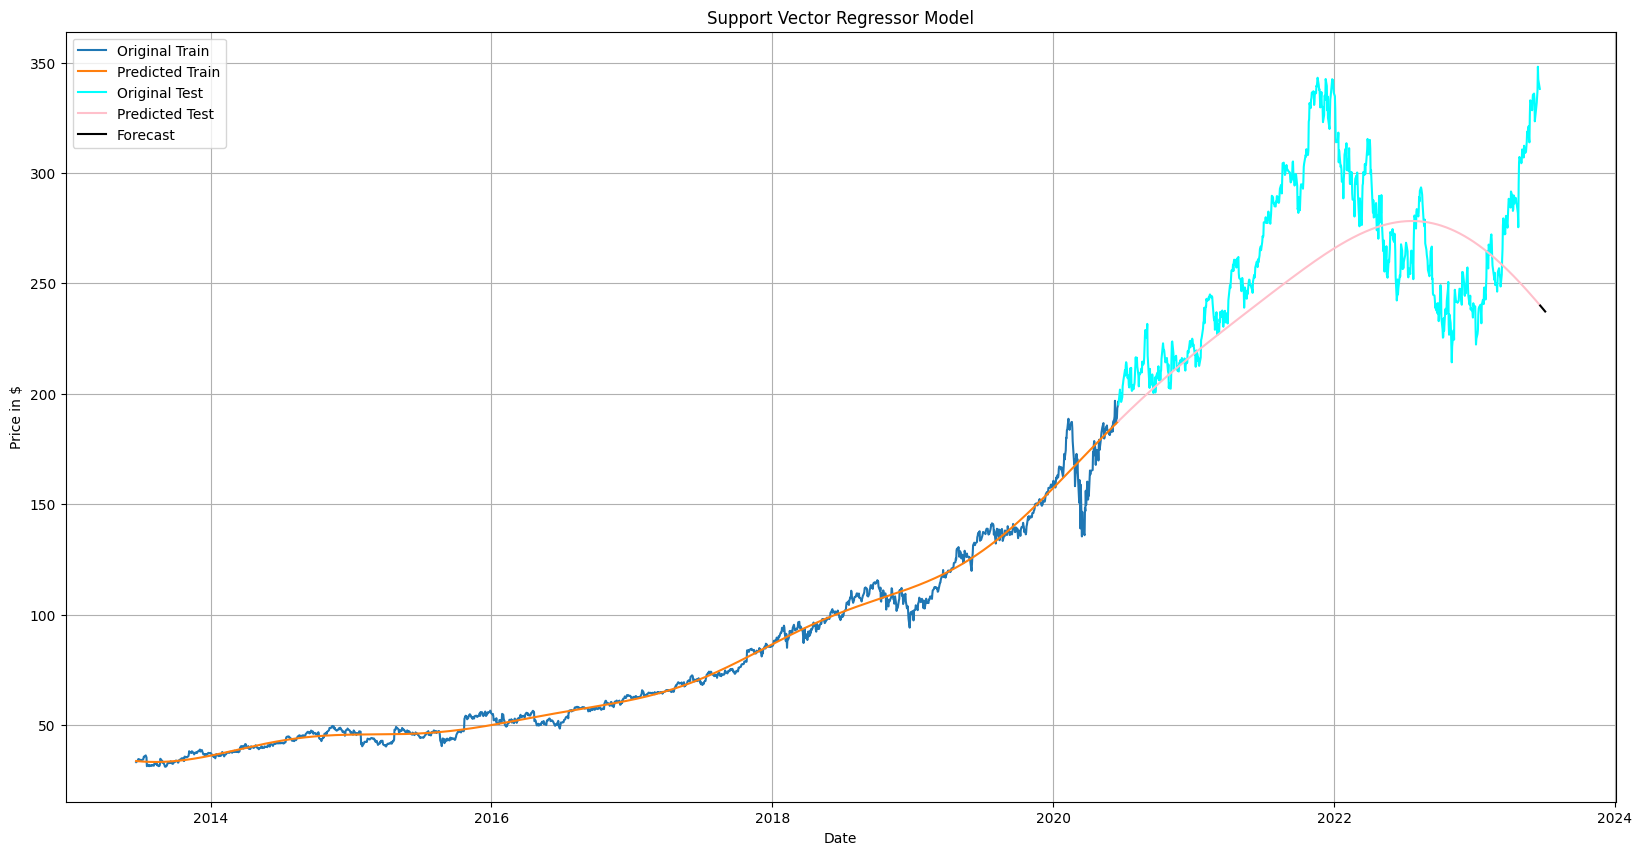

In [30]:
svr_model = SVR(kernel="rbf", C=100 ,gamma='scale', epsilon=0.0075)
svr_model.fit(feature_train,target_train_scaled)
pred_train = svr_model.predict(feature_train)
pred_test = svr_model.predict(feature_test)
svr_pred_train_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_train).reshape(-1,1)),columns = ['Close'])
svr_pred_test_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_test).reshape(-1,1)),columns = ['Close'])
forecast = svr_model.predict(feature_forecast)
forecast_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(forecast).reshape(-1,1)),columns = ['Close'])
plt.figure(figsize=(20,10))
plt.title('Support Vector Regressor Model')
plt.plot(data.index[:train_rec_count],target_train,label = 'Original Train')
plt.plot(data.index[:train_rec_count],svr_pred_train_unscaled,label = 'Predicted Train')
plt.plot(data.index[train_rec_count:],target_test,label = 'Original Test',color='aqua')
plt.plot(data.index[train_rec_count:],svr_pred_test_unscaled,label = 'Predicted Test',color='pink')
plt.plot(forecast_date,forecast_unscaled,label = 'Forecast',color='black')
plt.xlabel(labels['x'])
plt.ylabel(labels['y'])
plt.legend()
plt.grid(True)
plt.show()

In [31]:
print("\n-----------------------Support Vector Regressor Stats:-----------------------")
print('\n----------Train----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_train,svr_pred_train_unscaled)))
print('MSE: ',mean_squared_error(target_train,svr_pred_train_unscaled))
print('MAE: ',mean_absolute_error(target_train,svr_pred_train_unscaled))
print('\n----------Test----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_test,svr_pred_test_unscaled)))
print('MSE: ',mean_squared_error(target_test,svr_pred_test_unscaled))
print('MAE: ',mean_absolute_error(target_test,svr_pred_test_unscaled))
input('Press any key to continue')


-----------------------Support Vector Regressor Stats:-----------------------

----------Train----------
RMSE:  4.5012563871015425
MSE:  20.26130906242243
MAE:  2.756129994852334

----------Test----------
RMSE:  34.43753020950492
MSE:  1185.9434869305642
MAE:  26.619831461299466


''

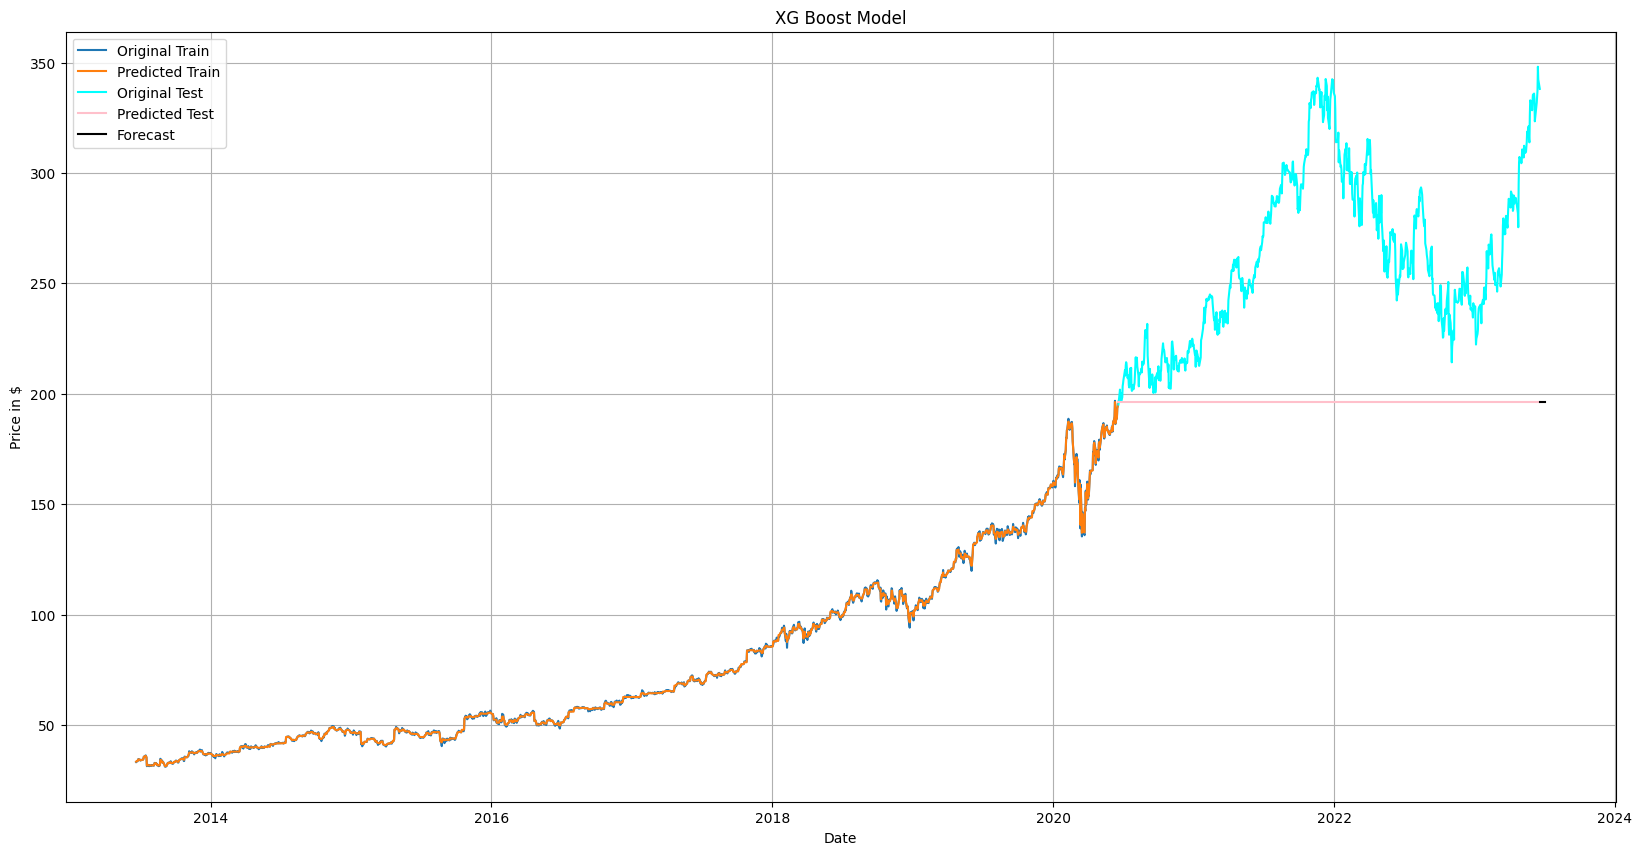

In [32]:
xgb_model = xgb.XGBRegressor()
xgb_model.fit(feature_train, target_train_scaled)

pred_train = xgb_model.predict(feature_train)
pred_test = xgb_model.predict(feature_test)
xgb_pred_train_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_train).reshape(-1,1)),columns = ['Close'])
xgb_pred_test_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(pred_test).reshape(-1,1)),columns = ['Close'])
forecast = xgb_model.predict(feature_forecast)
forecast_unscaled = pd.DataFrame(scaler.inverse_transform(np.array(forecast).reshape(-1,1)),columns = ['Close'])
plt.figure(figsize=(20,10))
plt.title('XG Boost Model')
plt.plot(data.index[:train_rec_count],target_train,label = 'Original Train')
plt.plot(data.index[:train_rec_count],xgb_pred_train_unscaled,label = 'Predicted Train')
plt.plot(data.index[train_rec_count:],target_test,label = 'Original Test',color='aqua')
plt.plot(data.index[train_rec_count:],xgb_pred_test_unscaled,label = 'Predicted Test',color='pink')
plt.plot(forecast_date,forecast_unscaled,label = 'Forecast',color='black')
plt.xlabel(labels['x'])
plt.ylabel(labels['y'])
plt.legend()
plt.grid(True)
plt.show()

In [33]:
print("\n-----------------------XG Boost Stats:-----------------------")
print('\n----------Train----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_train,xgb_pred_train_unscaled)))
print('MSE: ',mean_squared_error(target_train,xgb_pred_train_unscaled))
print('MAE: ',mean_absolute_error(target_train,xgb_pred_train_unscaled))
print('\n----------Test----------')
print('RMSE: ',np.sqrt(mean_squared_error(target_test,xgb_pred_test_unscaled)))
print('MSE: ',mean_squared_error(target_test,xgb_pred_test_unscaled))
print('MAE: ',mean_absolute_error(target_test,xgb_pred_test_unscaled))
input('Press any key to continue')


-----------------------XG Boost Stats:-----------------------

----------Train----------
RMSE:  0.4620942534359257
MSE:  0.2135310990585055
MAE:  0.3169400041050561

----------Test----------
RMSE:  76.67481393827252
MSE:  5879.02709246871
MAE:  66.66563104854356


''

In [100]:
# adf, pval, usedlag, nobs, crit_vals, icbest =  adfuller(target)
# print('\n-----------------------Original Data-----------------------')
# print('ADF test statistic:', adf)
# print('ADF p-values:', pval)
# print('ADF number of lags used:', usedlag)
# print('ADF number of observations:', nobs)
# print('ADF critical values:', crit_vals)
# print('ADF best information criterion:', icbest)


-----------------------Original Data-----------------------
ADF test statistic: -0.26001256788853383
ADF p-values: 0.9309799149103635
ADF number of lags used: 23
ADF number of observations: 2299
ADF critical values: {'1%': -3.433197593068361, '5%': -2.862798003151751, '10%': -2.5674396919684996}
ADF best information criterion: 8107.545400229783


In [101]:
# new_target = target - target.shift()
# adf, pval, usedlag, nobs, crit_vals, icbest =  adfuller(new_target.dropna())
# print('\n-----------------------Data After 1 shift-----------------------')
# print('ADF test statistic:', adf)
# print('ADF p-values:', pval)
# print('ADF number of lags used:', usedlag)
# print('ADF number of observations:', nobs)
# print('ADF critical values:', crit_vals)
# print('ADF best information criterion:', icbest)


-----------------------Data After 1 shift-----------------------
ADF test statistic: -11.659851312929785
ADF p-values: 1.9451951090571877e-21
ADF number of lags used: 22
ADF number of observations: 2299
ADF critical values: {'1%': -3.433197593068361, '5%': -2.862798003151751, '10%': -2.5674396919684996}
ADF best information criterion: 8103.035518210802


In [145]:
p = range(0,5)
q = range(0,5)
d= range(0,5)
pdq = list(itertools.product(p,d,q))

[(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 0, 4), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 1, 4), (0, 2, 0), (0, 2, 1), (0, 2, 2), (0, 2, 3), (0, 2, 4), (0, 3, 0), (0, 3, 1), (0, 3, 2), (0, 3, 3), (0, 3, 4), (0, 4, 0), (0, 4, 1), (0, 4, 2), (0, 4, 3), (0, 4, 4), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 0, 3), (1, 0, 4), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 1, 4), (1, 2, 0), (1, 2, 1), (1, 2, 2), (1, 2, 3), (1, 2, 4), (1, 3, 0), (1, 3, 1), (1, 3, 2), (1, 3, 3), (1, 3, 4), (1, 4, 0), (1, 4, 1), (1, 4, 2), (1, 4, 3), (1, 4, 4), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 0, 3), (2, 0, 4), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 1, 3), (2, 1, 4), (2, 2, 0), (2, 2, 1), (2, 2, 2), (2, 2, 3), (2, 2, 4), (2, 3, 0), (2, 3, 1), (2, 3, 2), (2, 3, 3), (2, 3, 4), (2, 4, 0), (2, 4, 1), (2, 4, 2), (2, 4, 3), (2, 4, 4), (3, 0, 0), (3, 0, 1), (3, 0, 2), (3, 0, 3), (3, 0, 4), (3, 1, 0), (3, 1, 1), (3, 1, 2), (3, 1, 3), (3, 1, 4), (3, 2, 0), (3, 2, 1), (3, 2, 2), (3, 2, 3), (3, 2, 4), (3, 3, 0)

In [34]:
def MAPE(actual,pred):
  mape = np.mean(np.abs((actual-pred)/actual))*100
  return mape

In [565]:
start_date = data.index[0].date()
end_date = data.index[-1].date()
dates = []
for i in data.index:
    dates.append(i.strftime('%Y-%m-%d'))
new_dates = []
delta = datetime.timedelta(days=1)
while start_date <= end_date:
    new_dates.append(pd.Timestamp(start_date))
    start_date += delta
arima_df = pd.DataFrame()
arima_df.index = new_dates
new_target = pd.DataFrame(target)
if nasdaq_market == True:
    column = 'Close/Last'
else:
    column = 'Close'
for i in dates:
    arima_df.loc[i,'Close'] = new_target.loc[i,column]
arima_df.fillna(method = 'ffill',inplace=True)
arima_train_df = arima_df.iloc[:int(arima_df.shape[0]*0.75)]
arima_test_df = arima_df.iloc[int(arima_df.shape[0]*0.75):]


In [579]:
lowest_aic, best_params = float("inf"), None

for i in tqdm(pdq):
  model = ARIMA(arima_train_df, order = i).fit()
  aic_m = model.aic
  # print(f'ARIMA{i} AIC={aic_m:.3f}')
  if lowest_aic == float('inf'):
    lowest_aic, best_params = aic_m, i
  if (aic_m < lowest_aic) and (aic_m > (lowest_aic*0.25)):
    lowest_aic, best_params = aic_m, i              

print(f'Best ARIMA {best_params} AIC={lowest_aic:.3f}')













































































































































































































































100%|██████████| 125/125 [03:27<00:00,  1.66s/it]

Best ARIMA (2, 2, 4) AIC=5729.093


In [580]:
arima1 = ARIMA(arima_train_df,order = best_params).fit()
arima1.aic

5729.093446386326

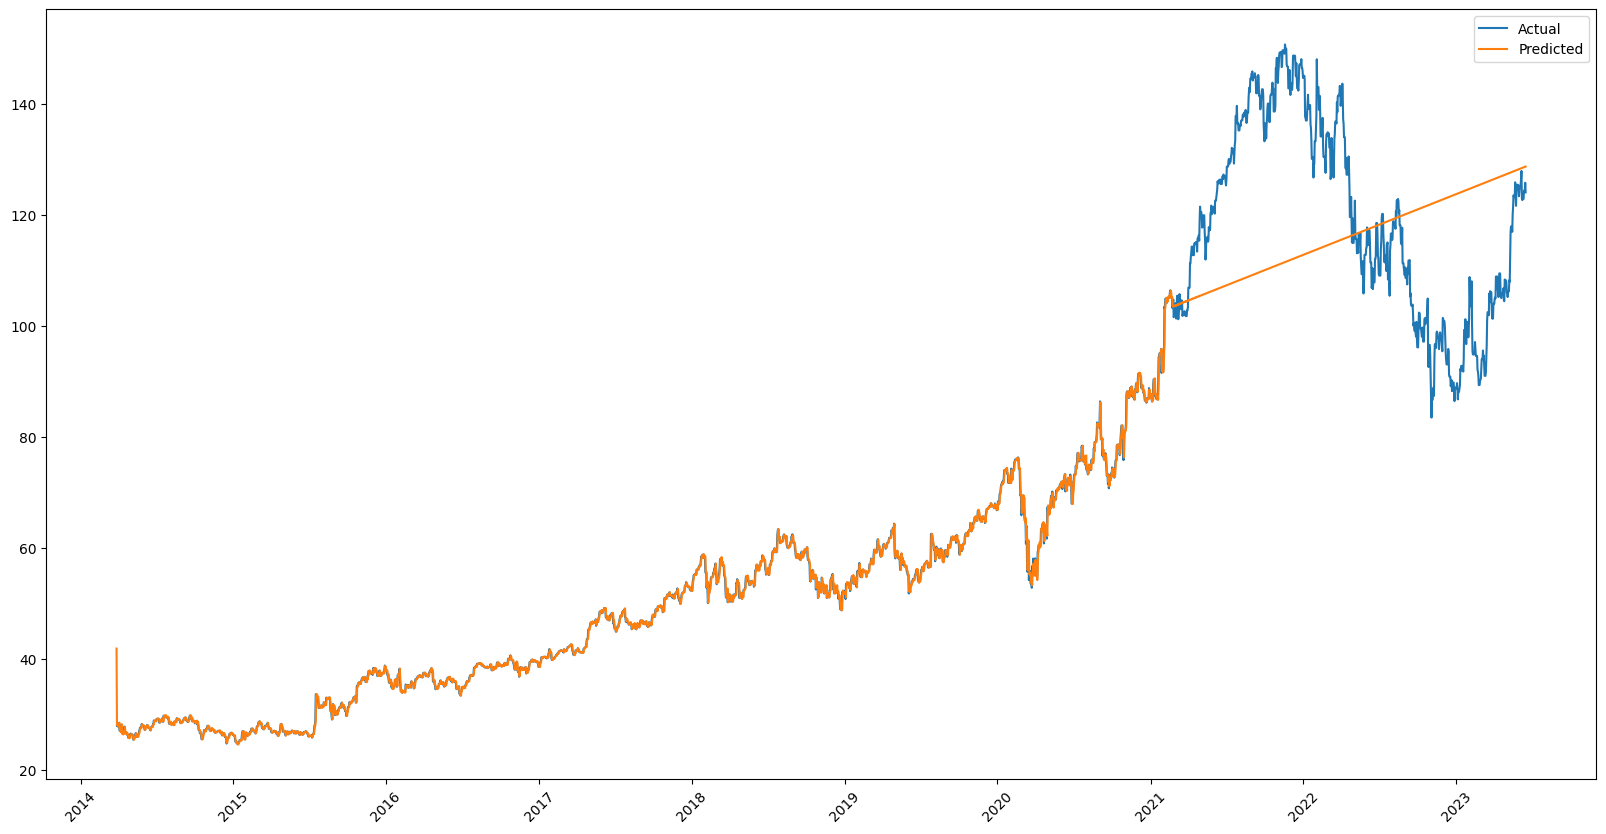

In [581]:
pred = pd.DataFrame(arima1.predict(start=1,end=arima_df.shape[0]-1,typ = 'linear')).rename(columns = {'predicted_mean':'Close'})
# Plot predictions and actual values
plt.figure(figsize = (20,10))
plt.plot(arima_df[best_params[1]:],label = 'Actual')
plt.plot(pred,label = 'Predicted')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [586]:
print("\n-----------------------ARIMA Stats:-----------------------")
print('\n----------Train----------')
print('RMSE: ',mean_squared_error(arima_train_df[best_params[1]:],pred[:int(arima_df.shape[0]*0.75)-best_params[1]])**0.5)
print('MSE: ',mean_squared_error(arima_train_df[best_params[1]:],pred[:int(arima_df.shape[0]*0.75)-best_params[1]]))
print('MAE: ',mean_absolute_error(arima_train_df[best_params[1]:],pred[:int(arima_df.shape[0]*0.75)-best_params[1]]))
print('MAPE: {0} %'.format(MAPE(arima_train_df[best_params[1]:],pred[:int(arima_df.shape[0]*0.75)]-best_params[1])))
print('\n----------Test----------')
print('RMSE: ',np.sqrt(mean_squared_error(arima_test_df,pred[int(arima_df.shape[0]*0.75)-1:])))
print('MSE: ',mean_squared_error(arima_test_df,pred[int(arima_df.shape[0]*0.75)-1:]))
print('MAE: ',mean_absolute_error(arima_test_df,pred[int(arima_df.shape[0]*0.75)-1:]))
print('MAPE: {0} %'.format(MAPE(arima_test_df,pred[int(arima_df.shape[0]*0.75)-1:])))
input('Press any key to continue')


-----------------------ARIMA Stats:-----------------------

----------Train----------
RMSE:  1.0671451039275073
MSE:  1.1387986728364503
MAE:  0.6235600054356408
MAPE: 4.716939080114766 %

----------Test----------
RMSE:  22.549595969301926
MSE:  508.4842783787576
MAE:  19.4854465309332
MAPE: 16.65466582979671 %


''

In [35]:
print('--Using Artificial Neural Network--\n')

start_date = data.index[0].date()
end_date = data.index[-1].date()
dates = []
for i in data.index:
    dates.append(pd.Timestamp(i.strftime('%Y-%m-%d')))
new_dates = []
delta = datetime.timedelta(days=1)
while start_date <= end_date:
    new_dates.append(pd.Timestamp(start_date))
    start_date += delta
ann_df = pd.DataFrame()
ann_df.index = new_dates
new_target = pd.DataFrame(target)
if nasdaq_market == True:
    column = 'Close/Last'
else:
    column = 'Close'
for i in dates:
    ann_df.loc[i,'Close'] = new_target.loc[i,column]
ann_df.fillna(method = 'ffill',inplace=True)
ann_train_rec = int(ann_df.shape[0]*0.75)
feature_train_ann = ann_df.index[:ann_train_rec].astype('int64')
feature_test_ann = ann_df.index[ann_train_rec:].astype('int64')
# feature_train_ann = pd.DataFrame(columns = ['Day','Month','Year'])
# feature_test_ann = pd.DataFrame(columns = ['Day','Month','Year'])
# for i in range(ann_df.shape[0]):
#     if i < ann_train_rec:
#         feature_train_ann.loc[i,'Day'] = ann_df.index[i].date().day
#         feature_train_ann.loc[i,'Month'] = ann_df.index[i].date().month
#         feature_train_ann.loc[i,'Year'] = ann_df.index[i].date().year
#     else:
#         feature_test_ann.loc[i,'Day'] = ann_df.index[i].date().day
#         feature_test_ann.loc[i,'Month'] = ann_df.index[i].date().month
#         feature_test_ann.loc[i,'Year'] = ann_df.index[i].date().year
# feature_train_ann = [np.asarray(feature_train_ann['Day']).astype('int32'),np.asarray(feature_train_ann['Month']).astype('int32'),np.asarray(feature_train_ann['Year']).astype('int32')]
# feature_test_ann = [np.asarray(feature_test_ann['Day']).astype('int32'),np.asarray(feature_test_ann['Month']).astype('int32'),np.asarray(feature_test_ann['Year']).astype('int32')]
target_train_ann = ann_df.iloc[:ann_train_rec].values
# target_train_ann_scaled = scaler.transform(target_train_ann)
target_test_ann = ann_df.iloc[ann_train_rec:].values
# target_test_ann_scaled = scaler.transform(target_test_ann)

In [541]:
feature_train_ann.shape

(2526,)

In [588]:
model = Sequential()
model.add(Dense(1000, input_shape = (feature_train.shape[1],), activation = 'relu')) # (features,)
model.add(Dense(500,activation='relu'))
model.add(Dense(250,activation='relu'))
model.add(Dense(50,activation='relu'))
model.add(Dense(1, activation= 'tanh'))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

es = EarlyStopping(monitor='val_loss',
                   mode='min',
                   patience=50,
                   restore_best_weights = True)


Model: "sequential_31"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_130 (Dense)           (None, 1000)              2000      
                                                                 
 dense_131 (Dense)           (None, 500)               500500    
                                                                 
 dense_132 (Dense)           (None, 250)               125250    
                                                                 
 dense_133 (Dense)           (None, 50)                12550     
                                                                 
 dense_134 (Dense)           (None, 1)                 51        
                                                                 
Total params: 640,351
Trainable params: 640,351
Non-trainable params: 0
_________________________________________________________________


In [589]:
history = model.fit(feature_train_ann, target_train_ann,
                    validation_data = (feature_test_ann, target_test_ann),
                    callbacks=[es],
                    epochs=500,
                    batch_size=40,
                    verbose=1)

Epoch 1/500
64/64 [==============================] - 4s 36ms/step - loss: 2791.6013 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 2/500
64/64 [==============================] - 2s 34ms/step - loss: 2791.6018 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 3/500
64/64 [==============================] - 3s 43ms/step - loss: 2791.6013 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 4/500
64/64 [==============================] - 3s 50ms/step - loss: 2791.6011 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 5/500
64/64 [==============================] - 3s 45ms/step - loss: 2791.6008 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 6/500
64/64 [==============================] - 3s 40ms/step - loss: 2791.6011 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 7/500
64/64 [==============================] - 3s 44ms/step - loss: 2791.6008 - mae: 49.8613 - val_loss: 14644.0205 - val_mae: 119.7162
Epoch 

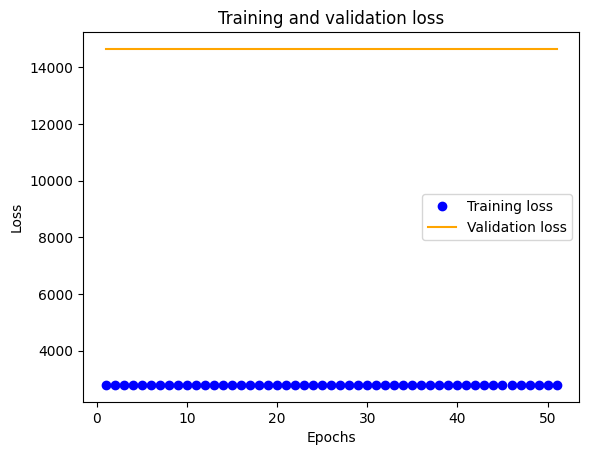

In [590]:
history_dict = history.history
loss_values = history_dict['loss'] # you can change this
val_loss_values = history_dict['val_loss'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'orange', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

27/27 [==============================] - 0s 6ms/step


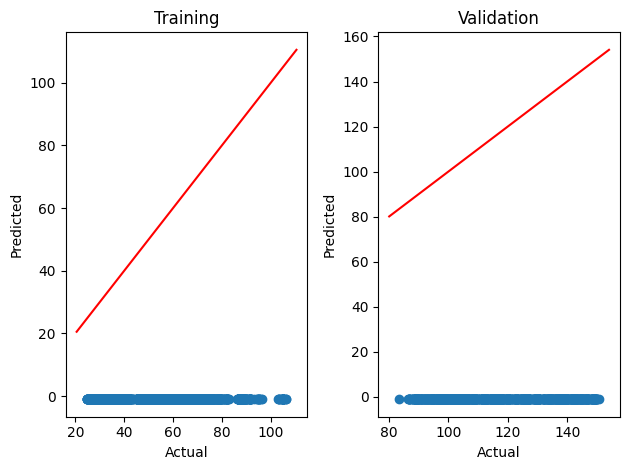

In [591]:

# scatterplot of actual vs. pred
# specify the dimensions 
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# this makes the individual subplots
# Training Results
axes[0].scatter(x=target_train_ann, y=model.predict(feature_train_ann))
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted",  fontsize=10)
axes[0].set_title("Training")
# add 45 deg line
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')
# Validation Results
axes[1].scatter(x=target_test_ann, y=model.predict(feature_test_ann)) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted",  fontsize=10)
axes[1].set_title("Validation")
# add 45 deg line
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# show the plot
plt.show()

## LSTM

In [40]:
target_train_ann = ann_df.iloc[:ann_train_rec]
target_test_ann = ann_df.iloc[ann_train_rec:]
scaler = MinMaxScaler()
scaler.fit(target_train_ann)


def get_combinations(parameters):
    return list(itertools.product(*parameters))

# def plot_keras_model(model, show_shapes=True, show_layer_names=True):
#     return SVG(model_to_dot(model, show_shapes=show_shapes, show_layer_names=show_layer_names).create(prog='dot',format='svg'))

def calculate_performance(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = MAPE(y_true, y_pred)
    rmse = (mean_squared_error(y_true, y_pred))**0.5
    return round(mse, 3), round(mae, 3), round(mape, 3), round(rmse, 3)

def preprocess_LSTM(data, look_back):
    data = np.array(data)[:, 0]
    X_train = []
    y_train = []
    for i in range(data.shape[0]-look_back):
        x = data[i:look_back+i][::-1]
        y = data[look_back+i]
        X_train.append(list(x))
        y_train.append(y)
    input_seq_for_test = data[i+1:look_back+i+1][::-1]
    return np.array(X_train), np.array(y_train), input_seq_for_test

def create_LSTM(input_nodes, hidden_nodes, output_nodes):
    model = Sequential()
    model.add(LSTM(hidden_nodes, input_shape=(1, input_nodes)))
    model.add(Dense(output_nodes))
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

def forecast_LSTM(model, input_sequence, future_steps):
    forecasted_values = []
    for i in range(future_steps):
        forecasted_value = model.predict(input_sequence)
        forecasted_values.append(forecasted_value[0][0])
        input_sequence[0][0] = np.append(forecasted_value, input_sequence[0][0][:-1])
    return forecasted_values

def train_model(model, X_train, y_train, epochs, batch_size):
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0, shuffle=False)
    return model

def Long_Short_Term_Memory(data, look_back, hidden_nodes, output_nodes, epochs, batch_size, future_steps, scaler):
    data = scaler.transform(data)
    X_train, y_train, input_seq_for_test_LSTM = preprocess_LSTM(data, look_back)
    X_train = np.reshape(X_train, (len(X_train), 1, look_back))

    model_LSTM = create_LSTM(input_nodes=look_back, hidden_nodes=hidden_nodes, output_nodes=output_nodes)
    # plot_keras_model(model_LSTM)
    model_LSTM = train_model(model_LSTM, X_train, y_train, epochs, batch_size)

    input_seq_for_test_LSTM = np.reshape(input_seq_for_test_LSTM, (1, 1, len(input_seq_for_test_LSTM)))
    forecasted_values_LSTM = forecast_LSTM(model_LSTM, input_sequence=input_seq_for_test_LSTM, future_steps=future_steps)
    
    forecasted_values_LSTM = list(scaler.inverse_transform([forecasted_values_LSTM])[0])
    
    return model_LSTM, forecasted_values_LSTM

def get_accuracies_LSTM(train_data, test_data, parameters, scaler):
    combination_of_params = get_combinations(parameters)
    information_LSTM = []
    iterator = 0
    print('LSTM - Number of combinations: ' + str(len(combination_of_params)))
    
    for param in combination_of_params:
        if (iterator+1) != len(combination_of_params):
            print(iterator+1, end=' -> ')
        else:
            print(iterator+1)
        iterator = iterator+1

        input_nodes = param[0]
        hidden_nodes = param[1]
        output_nodes = param[2]
        epochs = param[3]
        batch_size = param[4]
        future_steps = param[5]

        model_LSTM, forecasted_values_LSTM = Long_Short_Term_Memory(train_data, input_nodes, hidden_nodes, output_nodes, epochs, batch_size, future_steps, scaler)
        
        y_true = test_data.iloc[:future_steps].Close
        mse, mae, mape, rmse = calculate_performance(y_true, forecasted_values_LSTM)
        
        info = list(param) + [mse, mae, mape, rmse] + forecasted_values_LSTM
        information_LSTM.append(info)

    information_LSTM_df = pd.DataFrame(information_LSTM)
    indexes = [str(i) for i in list(range(1, future_steps+1))]
    information_LSTM_df.columns = ['look_back', 'hidden_nodes', 'output_nodes', 'epochs', 'batch_size', 'future_steps', 'MSE', 'MAE','MAPE', 'RMSE'] + indexes
    return information_LSTM_df

In [ ]:
# parameters_LSTM = [[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15], [3,4,5,6,7], [1], [300], [20], [15]]
# info_df = get_accuracies_LSTM(target_train_ann, target_test_ann, parameters_LSTM, scaler)
# info_df.to_csv('LSTM_info.csv',index=False)

In [41]:
info_df = get_accuracies_LSTM(target_train_ann, target_test_ann, [[12], [5], [1], [300], [20], [30]], scaler)

LSTM - Number of combinations: 1
1
1/1 [==============================] - 0s 27ms/step


In [42]:
info_df

,look_back,hidden_nodes,output_nodes,epochs,batch_size,future_steps,MSE,MAE,MAPE,RMSE,...,21,22,23,24,25,26,27,28,29,30
0,12,5,1,300,20,30,19.15,3.566,1.645,4.376,...,220.739545,220.741457,220.742366,220.742234,220.741852,220.741708,220.741935,220.742246,220.742378,220.742342


In [43]:
print("\n-----------------------LSTM Stats:-----------------------")
print('RMSE: ',info_df['RMSE'][0])
print('MSE: ',info_df['MSE'][0])
print('MAE: ',info_df['MAE'][0])
print('MAPE: {0} %'.format(info_df['MAPE'][0]))
input('Press any key to continue')


-----------------------LSTM Stats:-----------------------
RMSE:  4.376
MSE:  19.15
MAE:  3.566
MAPE: 1.645 %


''

In [45]:
ann_df

,Close
2013-06-21,33.265
2013-06-22,33.265
2013-06-23,33.265
2013-06-24,33.715
2013-06-25,33.670
...,...
2023-06-16,342.330
2023-06-17,342.330
2023-06-18,342.330
2023-06-19,342.330


In [47]:
print('--Forecast using LSTM--\n')
model_LSTM, forecasted_values_LSTM = Long_Short_Term_Memory(ann_df, 12, 5, 1, 300, 20, 30, scaler)
forecast_df = pd.DataFrame.from_dict({'Close (Actual)':list(ann_df[-30:].values.reshape(30))+[np.nan for i in range(30)],'Close (Forecast)':[np.nan for i in range(30)]+list(forecasted_values_LSTM)})
forecast_df.index = list(ann_df[-30:].index)+forecast_date
plt.figure(figsize = (20,10))
fig = px.line(forecast_df)
fig.show()


--Forecast using LSTM--



KeyboardInterrupt: 

            Close(Actual)  Close(Forecast)
2023-05-22         321.18              NaN
2023-05-23         315.26              NaN
2023-05-24         313.85              NaN
2023-05-25         325.92              NaN
2023-05-26         332.89              NaN
2023-05-27         332.89              NaN
2023-05-28         332.89              NaN
2023-05-29         332.89              NaN
2023-05-30         331.21              NaN
2023-05-31         328.39              NaN
2023-06-01         332.58              NaN
2023-06-02         335.40              NaN
2023-06-03         335.40              NaN
2023-06-04         335.40              NaN
2023-06-05         335.94              NaN
2023-06-06         333.68              NaN
2023-06-07         323.38              NaN
2023-06-08         325.26              NaN
2023-06-09         326.79              NaN
2023-06-10         326.79              NaN
2023-06-11         326.79              NaN
2023-06-12         331.85              NaN
2023-06-13 

<Figure size 2000x1000 with 0 Axes>